In [1]:
import numpy as np
import chemcoord as cc
import matplotlib.pyplot as plt
#import seaborn as sns

from ase.io.trajectory import Trajectory
from flonacomldft.utils.silver_isomers_utils import get_molecule_isomer_minima

from ase.visualize.plot import plot_atoms

# 1. Optimization trajectories

In [2]:
working_dir = "/home/amolina/ab-flowMC/ag8"
optimization_dir = working_dir + "/0-optimization"

In [3]:
ag8_trajs = {'0': Trajectory(optimization_dir + "/TPSS/optimization_ag8_0_20240902004423.traj"),
             '1': Trajectory(optimization_dir + "/TPSS/optimization_ag8_1_20240902005155.traj")}

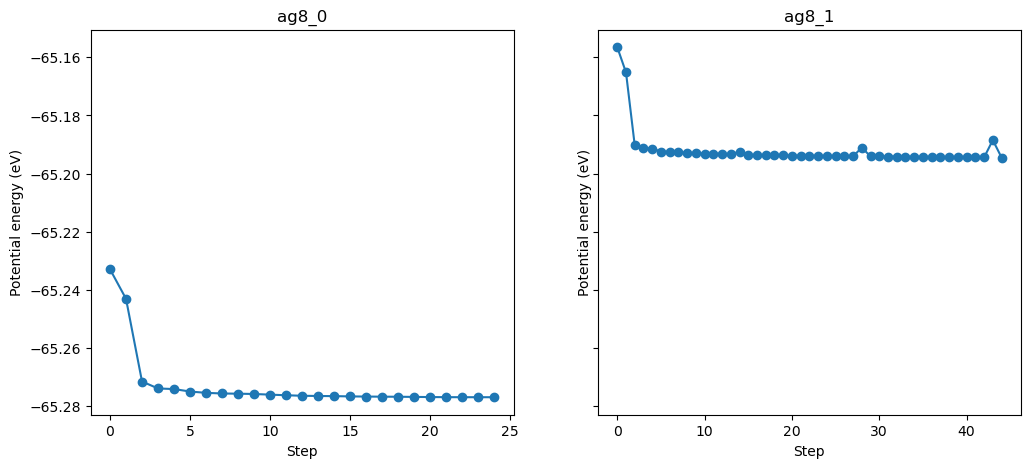

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for i, ag8 in ag8_trajs.items():
    pot_energy = [atoms.get_potential_energy() for atoms in ag8]
    axs[int(i)].plot(pot_energy, 'o-')
    axs[int(i)].set_xlabel('Step')
    axs[int(i)].set_ylabel('Potential energy (eV)')
    axs[int(i)].set_title(f'ag8_{i}')

In [5]:
ag8_minima = {'0': ag8_trajs['0'][-1],
              '1': ag8_trajs['1'][-1]}

for i, ag8 in ag8_minima.items():
    print(f"ag8_{i} minima positions:")
    print(ag8.get_positions())
    print(f"ag8_{i} minima energy:")
    print(f"{ag8.get_potential_energy()} eV")

ag8_0 minima positions:
[[7.64540586 5.42790676 6.25450181]
 [8.66670582 7.63903168 4.9925928 ]
 [7.98645493 5.51387775 8.9744954 ]
 [5.02250016 4.98742349 5.58867918]
 [5.56026287 6.2567737  7.94796841]
 [5.31922645 8.97604913 7.73840742]
 [7.82181303 7.87704663 7.58740301]
 [5.97609856 7.55149242 5.49325651]]
ag8_0 minima energy:
-65.27699982550996 eV
ag8_1 minima positions:
[[5.04220011 6.4580867  6.35989439]
 [7.14285719 5.03203647 7.43419719]
 [7.55573577 6.26285282 5.00532727]
 [8.37927369 6.08711868 9.58855927]
 [8.1875086  8.84955357 8.82901712]
 [9.1411193  6.94917615 7.08259654]
 [5.98923417 7.19636439 8.78110993]
 [6.89166867 8.50043396 6.48108234]]
ag8_1 minima energy:
-65.19449217282758 eV


# 1.a ag8 minima isomers

In [6]:
ag8_isomers = {'0': get_molecule_isomer_minima('FD-TPSS', 'Ag8', '0'),
               '1': get_molecule_isomer_minima('FD-TPSS', 'Ag8', '1'),
            }

for ag8 in ag8_isomers.values():
    ag8.center(vacuum=5)

<AxesSubplot:>

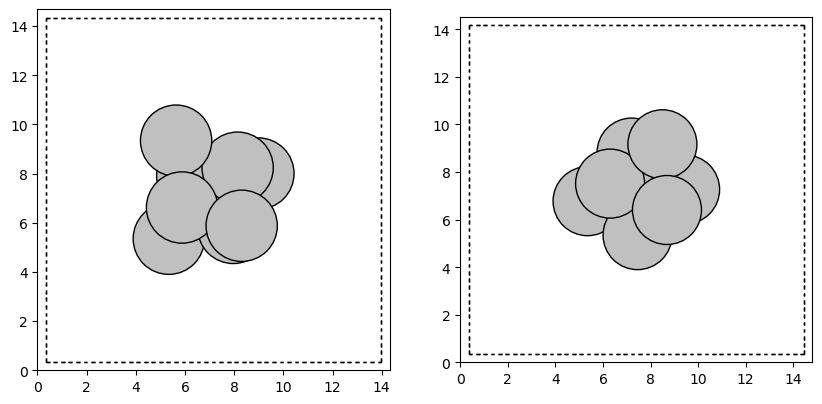

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

plot_atoms(ag8_isomers['0'], axs[0], rotation=('0x,0y,0z'))
plot_atoms(ag8_isomers['1'], axs[1], rotation=('0x,0y,0z'))

# 2. Minimal hopping

In [15]:
min_hopping_dir = working_dir + "/2-minimal-hopping"

In [16]:
min_hoppin_minima = {i: Trajectory(min_hopping_dir + f"/ag8_{i}/minima.traj") for i in ['0', '1']}

In [24]:
from pointgroup import PointGroup

def get_point_group_from_atoms(atoms):
    
    positions = atoms.get_positions()
    symbols = atoms.get_chemical_symbols()
    pg = PointGroup(positions=positions, symbols=symbols, tolerance_eig=0.1)
    
    return pg.get_point_group()
  

In [25]:
from ase.build.rotate import minimize_rotation_and_translation

In [26]:
min_hoppin_minima['0'][0].get_positions()

array([[7.6229057 , 5.44048327, 6.26190901],
       [8.64420566, 7.65160819, 5.        ],
       [7.96395477, 5.52645426, 8.9819026 ],
       [5.        , 5.        , 5.59608638],
       [5.53776271, 6.26935021, 7.95537561],
       [5.29672629, 8.98862564, 7.74581462],
       [7.79931287, 7.88962314, 7.59481021],
       [5.9535984 , 7.56406893, 5.50066371]])

In [27]:
min_hopping_pg = {}

for i, minima_traj in min_hoppin_minima.items():
    print(f"ag8_{i} minima point group:")
    #init_mol = get_molecule_isomer_minima('FD-TPSS', 'Ag8', i)
    for j, minima_atoms in enumerate(minima_traj):
        #minimize_rotation_and_translation(init_mol, minima_atoms)
        try:
            pd = get_point_group_from_atoms(minima_atoms)
            print(f"minima {j}: {get_point_group_from_atoms(minima_atoms)}")
        except:
            print(f"minima {j}: not found")

        # save xyz

        from ase.io import write
        write(min_hopping_dir + f"/ag8_{i}/minima_{j}.xyz", minima_atoms)

ag8_0 minima point group:
minima 0: Td
minima 1: Td
minima 2: Td
minima 3: Td
minima 4: Td
minima 5: Td
minima 6: Td
minima 7: Td
ag8_1 minima point group:
minima 0: D2d
minima 1: D2d
minima 2: D2d
minima 3: D2d
minima 4: D2d
minima 5: C1
minima 6: C1
minima 7: Cs
